# Random Forest / KNN baselines + learning curves

`RandomForestRegressor` và `KNeighborsRegressor` có thể chậm trên full data `65k x 1477`, nên notebook này mặc định dùng sample cap. Nếu máy chạy ổn, tăng `MAX_TRAIN_SIZE` và `VAL_EVAL_SIZE` ở cell config.

In [1]:
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)

In [2]:
DATA_PATH = Path('../processed_data/model_ready/gdsc2_lgbm_style_data.npz')
METADATA_PATH = Path('../processed_data/model_ready/artifacts/gdsc2_lgbm_style_metadata.json')
OUTPUT_DIR = Path('../models/random_forest_knn_baselines')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

loaded = np.load(DATA_PATH)
X_train = loaded['X_train']
y_train = loaded['y_train']
X_val = loaded['X_val']
y_val = loaded['y_val']
X_test = loaded['X_test']
y_test = loaded['y_test']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)
metadata

X_train: (65239, 1477) y_train: (65239,)
X_val:   (9233, 1477) y_val:   (9233,)
X_test:  (18231, 1477) y_test:  (18231,)


{'dataset': 'GDSC2',
 'split_method': 'cold_split by Cell Line_ID',
 'random_state': 42,
 'drug_feature': 'Morgan fingerprint 1024 bits',
 'cell_feature': 'StandardScaler + PCA fitted on train cell lines only',
 'cell_pca_components': 453,
 'X_train_shape': [65239, 1477],
 'X_val_shape': [9233, 1477],
 'X_test_shape': [18231, 1477],
 'saved_npz': '../processed_data/model_ready/gdsc2_lgbm_style_data.npz'}

## Config

Giữ cap vừa phải trước để notebook chạy nhanh. Sau khi biết model nào đáng thử tiếp, tăng dần cap hoặc bỏ cap.

In [3]:
RANDOM_STATE = 42
MAX_TRAIN_SIZE = 20000
VAL_EVAL_SIZE = min(5000, len(y_val))
TEST_EVAL_SIZE = min(5000, len(y_test))

rng = np.random.default_rng(RANDOM_STATE)
train_pool_idx = rng.permutation(len(y_train))[:MAX_TRAIN_SIZE]
val_eval_idx = rng.permutation(len(y_val))[:VAL_EVAL_SIZE]
test_eval_idx = rng.permutation(len(y_test))[:TEST_EVAL_SIZE]

print('Train pool:', len(train_pool_idx))
print('Validation eval:', len(val_eval_idx))
print('Test eval:', len(test_eval_idx))

Train pool: 20000
Validation eval: 5000
Test eval: 5000


In [4]:
def safe_corr(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def compute_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': safe_corr(y_true, y_pred),
    }


models = {
    'random_forest': RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    ),
    'knn_k15_distance': KNeighborsRegressor(
        n_neighbors=15,
        weights='distance',
        metric='minkowski',
        p=2,
        n_jobs=-1,
    ),
}

## 1. Fit baseline models

In [5]:
baseline_rows = []
fitted_models = {}

for model_name, model in models.items():
    print('Fitting', model_name)
    fitted = clone(model)
    start = time.time()
    fitted.fit(X_train[train_pool_idx], y_train[train_pool_idx])
    fit_seconds = time.time() - start

    val_pred = fitted.predict(X_val[val_eval_idx])
    test_pred = fitted.predict(X_test[test_eval_idx])

    row = {
        'model': model_name,
        'train_size': len(train_pool_idx),
        'val_eval_size': len(val_eval_idx),
        'test_eval_size': len(test_eval_idx),
        'fit_seconds': fit_seconds,
        **{f'val_{k}': v for k, v in compute_metrics(y_val[val_eval_idx], val_pred).items()},
        **{f'test_{k}': v for k, v in compute_metrics(y_test[test_eval_idx], test_pred).items()},
    }

    baseline_rows.append(row)
    fitted_models[model_name] = fitted
    joblib.dump(fitted, OUTPUT_DIR / f'{model_name}.joblib')
    np.save(OUTPUT_DIR / f'{model_name}_val_pred_sample.npy', val_pred)
    np.save(OUTPUT_DIR / f'{model_name}_test_pred_sample.npy', test_pred)

baseline_df = pd.DataFrame(baseline_rows).sort_values('val_rmse')
display(baseline_df.round(4))
baseline_df.to_csv(OUTPUT_DIR / 'random_forest_knn_baseline_results.csv', index=False)

Fitting random_forest
Fitting knn_k15_distance


,model,train_size,val_eval_size,test_eval_size,fit_seconds,val_rmse,val_mae,val_r2,val_pearson,test_rmse,test_mae,test_r2,test_pearson
0,random_forest,20000,5000,5000,4.8116,1.3999,1.0603,0.7185,0.8496,1.4044,1.0579,0.7230,0.8504
1,knn_k15_distance,20000,5000,5000,0.0483,2.6059,1.9820,0.0246,0.2388,2.6961,2.0449,-0.0208,0.2011


## 2. Learning curves

Fractions ở đây tính trên `MAX_TRAIN_SIZE`, không phải toàn bộ `X_train`.

In [6]:
def run_learning_curve(model_name, base_model, train_fractions):
    rows = []

    for fraction in train_fractions:
        sample_size = max(50, int(len(train_pool_idx) * fraction))
        sample_idx = train_pool_idx[:sample_size]

        model = clone(base_model)
        start = time.time()
        model.fit(X_train[sample_idx], y_train[sample_idx])
        fit_seconds = time.time() - start

        train_pred = model.predict(X_train[sample_idx])
        val_pred = model.predict(X_val[val_eval_idx])

        train_metrics = compute_metrics(y_train[sample_idx], train_pred)
        val_metrics = compute_metrics(y_val[val_eval_idx], val_pred)

        rows.append({
            'model': model_name,
            'train_fraction_of_cap': fraction,
            'train_size': sample_size,
            'val_eval_size': len(val_eval_idx),
            'fit_seconds': fit_seconds,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}': v for k, v in val_metrics.items()},
        })

    return pd.DataFrame(rows)


train_fractions = [0.1, 0.2, 0.4, 0.7, 1.0]
curve_parts = []

for model_name, model in models.items():
    print('Learning curve for', model_name)
    curve_parts.append(run_learning_curve(model_name, model, train_fractions))

learning_curve_df = pd.concat(curve_parts, ignore_index=True)
display(learning_curve_df.round(4))
learning_curve_df.to_csv(OUTPUT_DIR / 'random_forest_knn_learning_curves.csv', index=False)

Learning curve for random_forest
Learning curve for knn_k15_distance


,model,train_fraction_of_cap,train_size,val_eval_size,fit_seconds,train_rmse,train_mae,train_r2,train_pearson,val_rmse,val_mae,val_r2,val_pearson
0,random_forest,0.1,2000,5000,0.4115,0.7558,0.5800,0.9223,0.9724,1.5885,1.2349,0.6375,0.8041
1,random_forest,0.2,4000,5000,0.9595,0.6664,0.4948,0.9400,0.9758,1.4771,1.1317,0.6866,0.8299
2,random_forest,0.4,8000,5000,1.9658,0.6392,0.4645,0.9452,0.9768,1.4273,1.0866,0.7074,0.8420
3,random_forest,0.7,14000,5000,3.5056,0.6236,0.4484,0.9470,0.9770,1.4089,1.0684,0.7149,0.8469
4,random_forest,1.0,20000,5000,4.9641,0.6106,0.4409,0.9495,0.9779,1.3999,1.0603,0.7185,0.8496
5,knn_k15_distance,0.1,2000,5000,0.0020,0.0000,0.0000,1.0000,1.0000,2.7028,2.1366,-0.0493,0.1719
6,knn_k15_distance,0.2,4000,5000,0.0066,0.0000,0.0000,1.0000,1.0000,2.6348,2.0336,0.0028,0.2012
7,knn_k15_distance,0.4,8000,5000,0.0159,0.0075,0.0001,1.0000,1.0000,2.6331,2.0265,0.0041,0.1909
8,knn_k15_distance,0.7,14000,5000,0.0273,0.0347,0.0013,0.9998,0.9999,2.6435,2.0203,-0.0038,0.1958
9,knn_k15_distance,1.0,20000,5000,0.0694,0.0427,0.0024,0.9998,0.9999,2.6059,1.9820,0.0246,0.2388


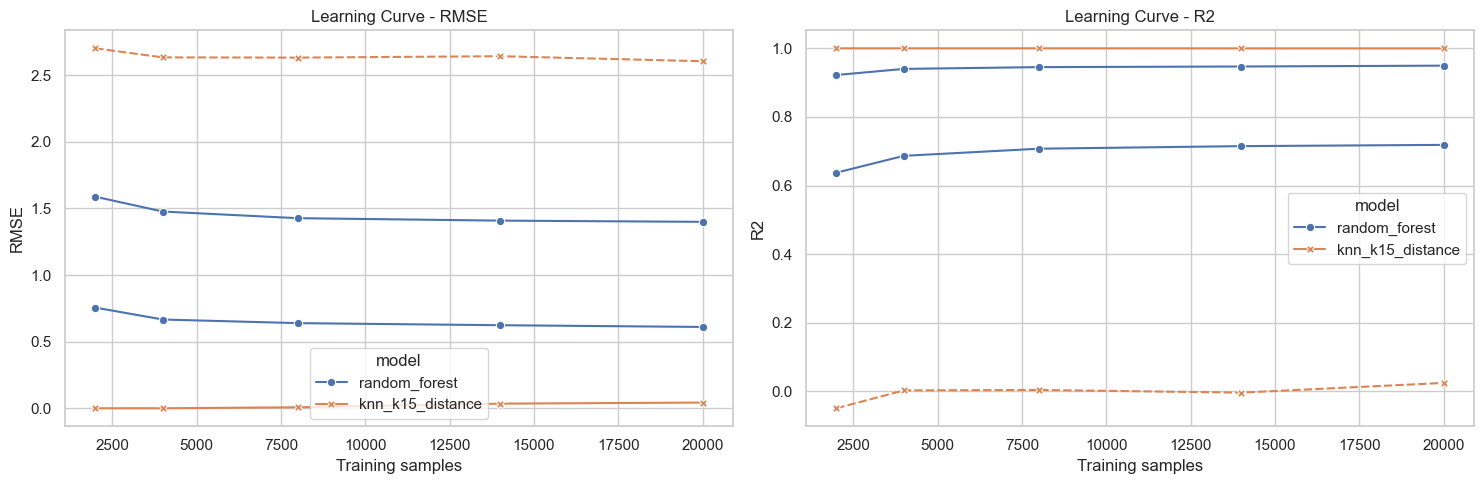

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='train_rmse',
    hue='model',
    style='model',
    markers=True,
    dashes=False,
    ax=axes[0],
)
sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='val_rmse',
    hue='model',
    style='model',
    markers=True,
    dashes=True,
    ax=axes[0],
    legend=False,
)
axes[0].set_title('Learning Curve - RMSE')
axes[0].set_xlabel('Training samples')
axes[0].set_ylabel('RMSE')

sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='train_r2',
    hue='model',
    style='model',
    markers=True,
    dashes=False,
    ax=axes[1],
)
sns.lineplot(
    data=learning_curve_df,
    x='train_size',
    y='val_r2',
    hue='model',
    style='model',
    markers=True,
    dashes=True,
    ax=axes[1],
    legend=False,
)
axes[1].set_title('Learning Curve - R2')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('R2')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'random_forest_knn_learning_curves.png', dpi=160, bbox_inches='tight')
plt.show()